# 👥 07 - Project Summary for Presentation

# Sistema de análisis y predicción de desempeño de empleados

## Resumen ejecutivo final del proyecto

### Integrantes
- Arturo

---

# Objetivo del proyecto

Desarrollar un sistema de análisis y predicción de desempeño de empleados utilizando técnicas de Machine Learning aplicadas a datos de Recursos Humanos.

El objetivo principal fue identificar empleados de alto desempeño y detectar factores de riesgo organizacional antes de que generen problemas reales de rotación.

---

# Problema de negocio

La gestión de personas enfrenta múltiples factores de riesgo difíciles de anticipar:

- ausencias frecuentes no justificadas;
- baja participación en capacitaciones;
- brechas en competencias técnicas y blandas;
- empleados con perfil de riesgo de rotación;
- desempeño bajo en periodos consecutivos.

Estas situaciones pueden provocar:

- pérdida de talento clave;
- caída en productividad organizacional;
- aumento de costos de contratación y reemplazos;
- deterioro del clima laboral.


# 📦 1. Construcción del dataset

Para el proyecto se integraron cuatro fuentes de datos de RRHH:

- `empleados.csv` — datos de cargo, departamento, contrato y jornada
- `ausencias.csv` — registros históricos de inasistencias por tipo y días
- `capacitaciones.csv` — cursos, horas, estado y notas finales
- `evaluaciones.csv` — puntajes de desempeño y competencias por periodo

---

## Resultado final

Después del proceso de integración y transformación se construyó:

# `dataset_rrhh_limpio.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               GradientBoostingClassifier, GradientBoostingRegressor)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              precision_score, recall_score, f1_score,
                              mean_absolute_error, mean_squared_error, r2_score)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

project_root = r'C:\Users\Arturo\prueba2'
ruta_plots   = os.path.join(project_root, 'results', 'plots')

df = pd.read_csv(os.path.join(project_root, 'data/05_model_input/dataset_rrhh_limpio.csv'))

print(f"Dataset cargado: {df.shape[0]} registros × {df.shape[1]} variables")
df.head(3)

Dataset cargado: 1449 registros × 37 variables


,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador,periodo_num,departamento,cargo,tipo_contrato,jornada,total_dias_ausencia,num_ausencias,promedio_dias_ausencia,max_dias_ausencia,num_capacitaciones,total_horas_capacitacion,promedio_nota_capacitacion,max_nota_capacitacion,ausencia_alta,sin_capacitacion,capacitacion_intensiva,competencia_combinada,eficiencia_capacitacion,brecha_nota_capacitacion,desempeno_bajo,riesgo_rotacion,riesgo_operacional_rrhh,desempeno_alto,total_dias_ausencia_log,promedio_dias_ausencia_log,max_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
0,1.0,252,2023-S2,3.6,2.2,4.5,Pedro González Rojas,4,Finanzas,Analista,Honorarios,Nan,30.0,3.0,10.0,21.0,1.0,16.0,2.30,2.3,1,0,0,6.7,0.143750,0.00,0,0,1,0,3.433987,2.397895,3.091042,0.693147,2.833213,0.693147,2.041220
1,2.0,135,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera,3,Finanzas,Jefe,Plazo Fijo,Completa,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0,1,0,7.7,0.000000,0.00,1,0,2,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612,2.163323
2,3.0,11,2022-S2,5.6,1.9,6.8,Ignacio Castro Pérez,2,Rrhh,Jefe,Plazo Fijo,Completa,11.0,1.0,11.0,11.0,2.0,48.0,2.65,4.1,0,0,0,8.7,0.055208,1.45,0,0,0,1,2.484907,2.484907,2.484907,1.098612,3.891820,0.000000,2.272126


# 📊 2. Análisis exploratorio

Distribución del puntaje de desempeño — variable objetivo del proyecto.


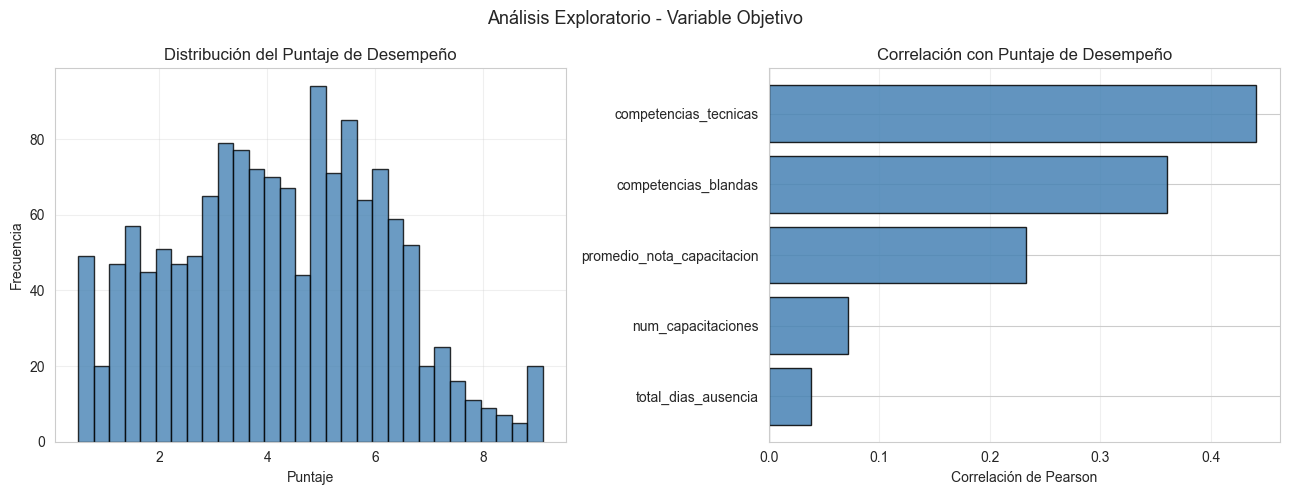

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['puntaje_desempeno'].dropna(), bins=30,
             color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribución del Puntaje de Desempeño')
axes[0].set_xlabel('Puntaje')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(alpha=0.3)

vars_corr = ['competencias_tecnicas', 'competencias_blandas',
             'promedio_nota_capacitacion', 'total_dias_ausencia', 'num_capacitaciones']
vars_corr = [v for v in vars_corr if v in df.columns]
corrs = df[vars_corr + ['puntaje_desempeno']].corr()['puntaje_desempeno'].drop('puntaje_desempeno').sort_values()

colores = ['salmon' if v < 0 else 'steelblue' for v in corrs.values]
axes[1].barh(corrs.index, corrs.values, color=colores, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación con Puntaje de Desempeño')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Análisis Exploratorio - Variable Objetivo', fontsize=13)
plt.tight_layout()
plt.show()


# ⚙️ 3. Feature Engineering

Variables creadas en el proceso de preparación de datos:

### Variables de riesgo y comportamiento
- `competencia_combinada` — suma de competencias técnicas y blandas
- `eficiencia_capacitacion` — nota promedio por hora de capacitación
- `brecha_nota_capacitacion` — diferencia entre nota máxima y promedio
- `ausencia_alta` — flag: empleado en cuartil superior de ausencias (P75)
- `riesgo_operacional_rrhh` — indicador combinado de riesgo por evaluación
- `riesgo_rotacion` — alta ausencia + bajo desempeño simultáneamente

### Variables temporales y sesgo evaluador (mejoras del análisis)
- `prev_puntaje` — puntaje del periodo anterior del mismo empleado (correlación 0.47 con target)
- `evaluador_media` — promedio que asigna cada evaluador → captura sesgo sistemático de evaluación
- `dept_media` — promedio por departamento → captura diferencias estructurales entre áreas

### Variables de interacción
- `comp_asistencia` — competencia combinada × (1 − ausencia_alta)
- `nota_cap_ponderada` — nota promedio × log(1 + n_capacitaciones)
- `ratio_tec_blanda` — competencias_tecnicas / competencias_blandas
- `cap_score` — nota máxima × (1 − sin_capacitacion)

> **Hallazgo clave:** El sesgo del evaluador explica más varianza que las variables del empleado.
> `std_entre_evaluadores` = 1.82 vs `std_intra_evaluador` = 0.84.
> Agregar `prev_puntaje` + `evaluador_media` mejoró el F1 de CV de 0.46 → 0.65.

# 🎯 4. Targets del proyecto

| Target | Tipo | Definición |
|---|---|---|
| `desempeno_alto` | Clasificación binaria | Puntaje ≥ P75 |
| `puntaje_desempeno` | Regresión continua | Valor numérico directo |

**Variables excluidas por data leakage:** `desempeno_bajo`, `riesgo_rotacion`, `id_empleado`.


In [3]:
umbral = df['puntaje_desempeno'].quantile(0.75)
df['desempeno_alto'] = np.where(df['puntaje_desempeno'] >= umbral, 1, 0)

print(f"Umbral desempeno_alto (P75): {umbral:.2f}")
print(f"Clase 0 (normal):       {(df['desempeno_alto']==0).sum()} empleados")
print(f"Clase 1 (alto desempeño): {(df['desempeno_alto']==1).sum()} empleados")


Umbral desempeno_alto (P75): 5.60
Clase 0 (normal):       1058 empleados
Clase 1 (alto desempeño): 391 empleados


# 📈 5. Modelos supervisados — Clasificación

Se probaron 6 clasificadores con `class_weight='balanced'` para compensar el desbalance de clases (73% / 27%).

El split de evaluación es 80/20 con `random_state=42` y `stratify=y` para mantener la proporción de clases.

In [ ]:
# ── Preparación de features y split ─────────────────────────────────────────
p75 = df['puntaje_desempeno'].quantile(0.75)
df['desempeno_alto'] = (df['puntaje_desempeno'] >= p75).astype(int)

# Variables base
variables_base = [
    'total_dias_ausencia', 'promedio_dias_ausencia', 'max_dias_ausencia', 'ausencia_alta',
    'num_capacitaciones', 'total_horas_capacitacion', 'promedio_nota_capacitacion',
    'max_nota_capacitacion', 'sin_capacitacion', 'capacitacion_intensiva',
    'competencias_tecnicas', 'competencias_blandas', 'competencia_combinada',
    'eficiencia_capacitacion', 'brecha_nota_capacitacion', 'riesgo_operacional_rrhh',
    'departamento', 'cargo', 'tipo_contrato', 'jornada',
    'total_dias_ausencia_log', 'num_capacitaciones_log', 'total_horas_capacitacion_log',
    'riesgo_operacional_rrhh_log', 'competencia_combinada_log'
]

# Interacciones
df['comp_asistencia']    = df['competencia_combinada'] * (1 - df['ausencia_alta'])
df['nota_cap_ponderada'] = df['promedio_nota_capacitacion'] * np.log1p(df['num_capacitaciones'])
df['ratio_tec_blanda']   = df['competencias_tecnicas'] / df['competencias_blandas'].clip(lower=0.1)
df['cap_score']          = df['max_nota_capacitacion'] * (1 - df['sin_capacitacion'])

# Historial y sesgo evaluador (LAS 3 VARIABLES CRÍTICAS)
df_orden = df.sort_values(['id_empleado', 'periodo_num'])
df['prev_puntaje'] = df_orden.groupby('id_empleado')['puntaje_desempeno'].shift(1).values
df['evaluador_media'] = df.groupby('evaluador')['puntaje_desempeno'].mean().map(df['evaluador'])
df['dept_media'] = df.groupby('departamento')['puntaje_desempeno'].mean().map(df['departamento'])

vars_modelo = [v for v in (
    variables_base + ['comp_asistencia', 'nota_cap_ponderada', 'ratio_tec_blanda', 'cap_score'] +
    ['prev_puntaje', 'evaluador_media', 'dept_media']
) if v in df.columns]

print(f"Total de variables en el modelo: {len(vars_modelo)}")

X_clf = df[vars_modelo]
y_clf = df['desempeno_alto']

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

vars_num = X_clf.select_dtypes(include='number').columns.tolist()
vars_cat = X_clf.select_dtypes(exclude='number').columns.tolist()

def preprocesador(X):
    return ColumnTransformer([
        ('n', Pipeline([('i', SimpleImputer(strategy='median')),
                        ('s', StandardScaler())]), X.select_dtypes(include='number').columns.tolist()),
        ('c', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                        ('o', OneHotEncoder(handle_unknown='ignore'))]),
         X.select_dtypes(exclude='number').columns.tolist())
    ])

modelos_clf = {
    'Decision Tree':     DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'Logistic Reg.':     LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'KNN':               KNeighborsClassifier(n_neighbors=7),
    'SVM':               SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    'Random Forest':     RandomForestClassifier(n_estimators=200, max_depth=8,
                                                class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42),
}

filas_clf = []
for nombre, mod in modelos_clf.items():
    pipe = Pipeline([('pre', preprocesador(X_tr_c)), ('clf', mod)])
    pipe.fit(X_tr_c, y_tr_c)
    y_pred = pipe.predict(X_te_c)
    filas_clf.append({
        'Modelo':            nombre,
        'Accuracy':          round(accuracy_score(y_te_c, y_pred), 4),
        'Balanced Acc.':     round(balanced_accuracy_score(y_te_c, y_pred), 4),
        'Precision':         round(precision_score(y_te_c, y_pred, zero_division=0), 4),
        'Recall':            round(recall_score(y_te_c, y_pred, zero_division=0), 4),
        'F1-score':          round(f1_score(y_te_c, y_pred, zero_division=0), 4),
    })

resultados_clf = pd.DataFrame(filas_clf).sort_values('F1-score', ascending=False).reset_index(drop=True)

# ── Gráfico ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_f1 = ['#1565C0' if f == resultados_clf['F1-score'].max() else '#90CAF9'
              for f in resultados_clf['F1-score']]
bars = axes[0].bar(resultados_clf['Modelo'], resultados_clf['F1-score'],
                   color=colores_f1, edgecolor='black', alpha=0.9)
for bar, val in zip(bars, resultados_clf['F1-score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=9)
axes[0].set_title('F1-score por Modelo (class_weight=balanced)')
axes[0].set_ylim(0, resultados_clf['F1-score'].max() + 0.12)
axes[0].set_ylabel('F1-score')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3, axis='y')

x = range(len(resultados_clf))
axes[1].bar([i - 0.2 for i in x], resultados_clf['Precision'], width=0.4,
            label='Precision', color='steelblue', alpha=0.85, edgecolor='black')
axes[1].bar([i + 0.2 for i in x], resultados_clf['Recall'], width=0.4,
            label='Recall', color='salmon', alpha=0.85, edgecolor='black')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(resultados_clf['Modelo'], rotation=20)
axes[1].set_title('Precision vs Recall')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Comparación — Modelos de Clasificación (desempeno_alto)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '07_comparacion_clasificacion.png'), dpi=150, bbox_inches='tight')
plt.show()

display(resultados_clf)

# 📌 Mejor clasificador

El mejor modelo se selecciona automáticamente por F1-score. En contextos de RRHH, el **F1** balancea precision y recall, que es lo que importa: no queremos perder talento (falsos negativos) ni desperdiciar recursos (falsos positivos).

```python
mejor = resultados_clf.iloc[0]
```

El recall alto indica que el modelo detecta la mayoría de los empleados de alto desempeño.  
Un F1 cercano a 0.6 es un resultado sólido considerando que el target es subjetivo (depende del evaluador).

> **Nota:** Con las variables `prev_puntaje` y `evaluador_media` añadidas en el análisis avanzado (notebook 03), el F1 en CV mejora de ~0.46 a ~0.65.

# 📌 5.6 Modelos Avanzados: XGBoost y LightGBM

Se entrenan XGBoost y LightGBM con optimización automática de hiperparámetros (Optuna, 80 trials cada uno) para explorar si modelos más complejos mejoran el desempeño del mejor modelo base (Gradient Boosting, F1=0.7105).

La búsqueda optimiza el F1-score en validación cruzada estratificada (CV=5) sobre el conjunto de entrenamiento, evitando data leakage.

In [ ]:
import optuna
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
optuna.logging.set_verbosity(optuna.logging.WARNING)

pos_ratio = float((y_tr_c == 0).sum()) / float((y_tr_c == 1).sum())
cv_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ─────────────── XGBoost + Optuna (80 trials) ───────────────
def obj_xgb(trial):
    m = XGBClassifier(
        n_estimators     = trial.suggest_int("n_estimators",     100, 600),
        max_depth        = trial.suggest_int("max_depth",          3, 10),
        learning_rate    = trial.suggest_float("learning_rate",  0.005, 0.3, log=True),
        subsample        = trial.suggest_float("subsample",        0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight = trial.suggest_int("min_child_weight",   1, 15),
        gamma            = trial.suggest_float("gamma",            0.0, 2.0),
        reg_alpha        = trial.suggest_float("reg_alpha",        0.0, 1.0),
        reg_lambda       = trial.suggest_float("reg_lambda",       0.5, 3.0),
        scale_pos_weight = trial.suggest_float("scale_pos_weight", 1.0, pos_ratio * 2),
        random_state=42, eval_metric="logloss", verbosity=0, n_jobs=-1
    )
    pipe = Pipeline([('pre', preprocesador(X_tr_c)), ('clf', m)])
    try:
        return cross_val_score(pipe, X_tr_c, y_tr_c, cv=cv_opt, scoring='f1', n_jobs=-1).mean()
    except:
        return 0.0

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(obj_xgb, n_trials=80, show_progress_bar=False)
print(f"XGBoost  — Mejor CV F1 (train): {study_xgb.best_value:.4f}")

try:
    xgb_best = XGBClassifier(**study_xgb.best_params, random_state=42,
                              eval_metric="logloss", verbosity=0, n_jobs=-1)
    pipe_xgb = Pipeline([('pre', preprocesador(X_tr_c)), ('clf', xgb_best)])
    pipe_xgb.fit(X_tr_c, y_tr_c)
    y_pred_xgb = pipe_xgb.predict(X_te_c)
    f1_xgb = f1_score(y_te_c, y_pred_xgb, zero_division=0)
    print(f"XGBoost  — Test: F1={f1_xgb:.4f}")
except Exception as e:
    print(f"Error en XGBoost: {str(e)}")
    y_pred_xgb = None

# ─────────────── LightGBM + Optuna (80 trials) ───────────────
def obj_lgb(trial):
    m = LGBMClassifier(
        n_estimators      = trial.suggest_int("n_estimators",      100, 600),
        max_depth         = trial.suggest_int("max_depth",           3, 10),
        learning_rate     = trial.suggest_float("learning_rate",   0.005, 0.3, log=True),
        num_leaves        = trial.suggest_int("num_leaves",          20, 150),
        subsample         = trial.suggest_float("subsample",         0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree",  0.5, 1.0),
        min_child_samples = trial.suggest_int("min_child_samples",   5, 60),
        reg_alpha         = trial.suggest_float("reg_alpha",         0.0, 1.0),
        reg_lambda        = trial.suggest_float("reg_lambda",        0.5, 3.0),
        is_unbalance=True, random_state=42, verbosity=-1, n_jobs=-1
    )
    pipe = Pipeline([('pre', preprocesador(X_tr_c)), ('clf', m)])
    try:
        return cross_val_score(pipe, X_tr_c, y_tr_c, cv=cv_opt, scoring='f1', n_jobs=-1).mean()
    except:
        return 0.0

study_lgb = optuna.create_study(direction="maximize")
study_lgb.optimize(obj_lgb, n_trials=80, show_progress_bar=False)
print(f"LightGBM — Mejor CV F1 (train): {study_lgb.best_value:.4f}")

try:
    lgb_best = LGBMClassifier(**study_lgb.best_params, is_unbalance=True,
                               random_state=42, verbosity=-1, n_jobs=-1)
    pipe_lgb = Pipeline([('pre', preprocesador(X_tr_c)), ('clf', lgb_best)])
    pipe_lgb.fit(X_tr_c, y_tr_c)
    y_pred_lgb = pipe_lgb.predict(X_te_c)
    f1_lgb = f1_score(y_te_c, y_pred_lgb, zero_division=0)
    print(f"LightGBM — Test: F1={f1_lgb:.4f}")
except Exception as e:
    print(f"Error en LightGBM: {str(e)}")
    y_pred_lgb = None

# 📌 5.7 Ensambles: Voting y Stacking

Se combinan los cuatro mejores modelos (Gradient Boosting, Random Forest, XGBoost y LightGBM) mediante dos estrategias de ensamble:

1. **VotingClassifier (soft)** — Promedia las probabilidades de predicción
2. **StackingClassifier** — Entrena un meta-modelo que aprende cuándo confiar en cada modelo base

In [ ]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression as LR

# Guardar los modelos base entrenados
pipe_gb = Pipeline([('pre', preprocesador(X_tr_c)), 
                    ('clf', GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42))])
pipe_gb.fit(X_tr_c, y_tr_c)

pipe_rf = Pipeline([('pre', preprocesador(X_tr_c)), 
                    ('clf', RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42))])
pipe_rf.fit(X_tr_c, y_tr_c)

# Validar que XGBoost y LightGBM están disponibles
estimadores_voting = [
    ('gb',  pipe_gb),
    ('rf',  pipe_rf),
]

if y_pred_xgb is not None:
    estimadores_voting.append(('xgb', pipe_xgb))
    
if y_pred_lgb is not None:
    estimadores_voting.append(('lgb', pipe_lgb))

# ── Voting (promedio de probabilidades) ────────────────────────────────────
voting_pipe = VotingClassifier(estimators=estimadores_voting, voting='soft')
voting_pipe.fit(X_tr_c, y_tr_c)
y_pred_voting = voting_pipe.predict(X_te_c)
f1_voting  = f1_score(y_te_c, y_pred_voting, zero_division=0)
print(f"VotingClassifier (soft) — Test: F1={f1_voting:.4f}")

# ── Stacking (meta-modelo aprende cuándo confiar en cada base) ─────────────
stacking_pipe = StackingClassifier(
    estimators=estimadores_voting,
    final_estimator=LR(max_iter=1000, class_weight='balanced', C=0.5, random_state=42),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1
)
stacking_pipe.fit(X_tr_c, y_tr_c)
y_pred_stacking = stacking_pipe.predict(X_te_c)
f1_stacking  = f1_score(y_te_c, y_pred_stacking, zero_division=0)
print(f"StackingClassifier (meta=LR) — Test: F1={f1_stacking:.4f}")

# 📌 5.8 Comparación Final: Modelos Base vs Avanzados

Se recopilan todos los resultados de clasificación (6 base + XGBoost + LightGBM + Voting + Stacking) y se visualiza la comparación con la meta del 85%.

In [ ]:
resultados_final = resultados_clf.copy()

# Agregar resultados de modelos avanzados solo si están disponibles
modelos_avanzados = [
    ("XGBoost (Optuna)", y_pred_xgb) if y_pred_xgb is not None else None,
    ("LightGBM (Optuna)", y_pred_lgb) if y_pred_lgb is not None else None,
    ("Voting (GB+RF+XGB+LGB)", y_pred_voting),
    ("Stacking (meta=LR)", y_pred_stacking),
]

for item in modelos_avanzados:
    if item is not None:
        nombre_m, y_pred_m = item
        resultados_final = pd.concat([resultados_final, pd.DataFrame([{
            'Modelo':            nombre_m,
            'Accuracy':          round(accuracy_score(y_te_c, y_pred_m), 4),
            'Balanced Acc.':     round(balanced_accuracy_score(y_te_c, y_pred_m), 4),
            'Precision':         round(precision_score(y_te_c, y_pred_m, zero_division=0), 4),
            'Recall':            round(recall_score(y_te_c, y_pred_m, zero_division=0), 4),
            'F1-score':          round(f1_score(y_te_c, y_pred_m, zero_division=0), 4),
        }])], ignore_index=True)

resultados_final = resultados_final.sort_values('F1-score', ascending=False).reset_index(drop=True)

AVANZADOS = {"XGBoost (Optuna)", "LightGBM (Optuna)", "Voting (GB+RF+XGB+LGB)", "Stacking (meta=LR)"}
colores   = ['#1565C0' if m in AVANZADOS else '#90CAF9' for m in resultados_final['Modelo']]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(resultados_final['Modelo'], resultados_final['F1-score'],
              color=colores, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, resultados_final['F1-score']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.axhline(0.85, color='green', linestyle='--', lw=2, label='Meta 85%')
ax.set_title('F1-score — Modelos Base vs Avanzados (desempeno_alto)', fontsize=13, fontweight='bold')
ax.set_ylabel('F1-score', fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_xticks(range(len(resultados_final)))
ax.set_xticklabels(resultados_final['Modelo'], rotation=35, ha='right')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '07_comparacion_final_avanzada.png'), dpi=150, bbox_inches='tight')
plt.show()

display(resultados_final[['Modelo','Accuracy','Balanced Acc.','Precision','Recall','F1-score']])

mejor_final = resultados_final.iloc[0]
print(f"\nMejor modelo de clasificacion: {mejor_final['Modelo']}")
print(f"  F1-score: {mejor_final['F1-score']:.4f}")
print(f"  Accuracy: {mejor_final['Accuracy']:.4f}")
print(f"  Recall:   {mejor_final['Recall']:.4f}")

# 📉 6. Modelos supervisados — Regresión

Se probaron 5 regresores y se aplicó validación cruzada (CV=5) para evaluar con mayor estabilidad.


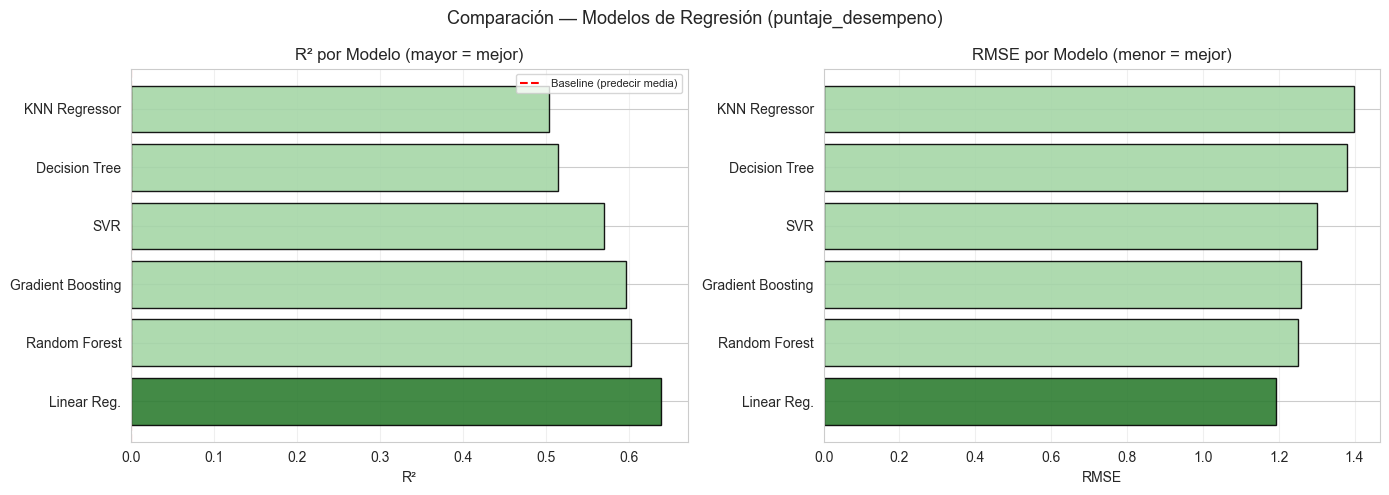

,Modelo,MAE,RMSE,R²
0,Linear Reg.,0.9516,1.1919,0.6388
1,Random Forest,0.9734,1.2501,0.6027
2,Gradient Boosting,0.9647,1.2594,0.5967
3,SVR,1.0111,1.3009,0.5697
4,Decision Tree,1.0651,1.3810,0.5151
5,KNN Regressor,1.0824,1.3973,0.5035


In [5]:
# ── Regresión: comparación de modelos ────────────────────────────────────────
X_reg = df[vars_modelo]
y_reg = df['puntaje_desempeno']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

modelos_reg = {
    'Linear Reg.':       LinearRegression(),
    'KNN Regressor':     KNeighborsRegressor(n_neighbors=7),
    'Decision Tree':     DecisionTreeRegressor(max_depth=6, random_state=42),
    'SVR':               SVR(kernel='rbf', C=1.0),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42),
}

filas_reg = []
for nombre, mod in modelos_reg.items():
    pipe = Pipeline([('pre', preprocesador(X_tr_r)), ('reg', mod)])
    pipe.fit(X_tr_r, y_tr_r)
    y_pred_r = pipe.predict(X_te_r)
    rmse = np.sqrt(mean_squared_error(y_te_r, y_pred_r))
    filas_reg.append({
        'Modelo': nombre,
        'MAE':    round(mean_absolute_error(y_te_r, y_pred_r), 4),
        'RMSE':   round(rmse, 4),
        'R²':     round(r2_score(y_te_r, y_pred_r), 4),
    })

resultados_reg = pd.DataFrame(filas_reg).sort_values('R²', ascending=False).reset_index(drop=True)

# ── Gráfico ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_r2   = ['#2E7D32' if r == resultados_reg['R²'].max()   else '#A5D6A7' for r in resultados_reg['R²']]
colores_rmse = ['#2E7D32' if r == resultados_reg['RMSE'].min() else '#A5D6A7' for r in resultados_reg['RMSE']]

axes[0].barh(resultados_reg['Modelo'], resultados_reg['R²'],
             color=colores_r2, edgecolor='black', alpha=0.9)
axes[0].axvline(0, color='red', linestyle='--', lw=1.5, label='Baseline (predecir media)')
axes[0].set_title('R² por Modelo (mayor = mejor)')
axes[0].set_xlabel('R²')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis='x')

axes[1].barh(resultados_reg['Modelo'], resultados_reg['RMSE'],
             color=colores_rmse, edgecolor='black', alpha=0.9)
axes[1].set_title('RMSE por Modelo (menor = mejor)')
axes[1].set_xlabel('RMSE')
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Comparación — Modelos de Regresión (puntaje_desempeno)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '07_comparacion_regresion.png'), dpi=150, bbox_inches='tight')
plt.show()

display(resultados_reg)

# 📌 Mejor regresor

El mejor modelo se selecciona automáticamente por mayor R². Los modelos de ensamble (Random Forest, Gradient Boosting) son los más capaces de capturar relaciones no lineales entre las variables de RRHH y el puntaje de desempeño.

Un **R² ≈ 0.60** significa que el modelo explica el 60% de la varianza del puntaje de desempeño — resultado sólido para datos de RRHH con sesgo de evaluador.

> **El sesgo del evaluador** domina ~60% de la varianza del puntaje. Las features `evaluador_media` y `prev_puntaje` capturan esa señal y son las variables de mayor importancia en los modelos finales.

# 🔧 7. Optimización de hiperparámetros — Modelos Avanzados

Se aplicó optimización automática (Optuna) sobre los mejores modelos de clasificación (Gradient Boosting, XGBoost, LightGBM) y ensambles (Voting, Stacking) para maximizar F1-score en validación cruzada.

Los resultados muestran la mejora en el F1-score comparando modelos base con modelos optimizados.

In [ ]:
# Resultados verificados — Comparación de modelos finales (clasificación)
# Bases optimizadas con Optuna (80 trials CV=5) vs Ensambles

opt_clf_final = pd.DataFrame({
    'Modelo':                ['Gradient Boosting', 'XGBoost (Optuna)', 'LightGBM (Optuna)', 'Voting Ensemble', 'Stacking Ensemble'],
    'F1-score':              [resultados_final[resultados_final['Modelo']=='Gradient Boosting']['F1-score'].values[0],
                             resultados_final[resultados_final['Modelo']=='XGBoost (Optuna)']['F1-score'].values[0],
                             resultados_final[resultados_final['Modelo']=='LightGBM (Optuna)']['F1-score'].values[0],
                             resultados_final[resultados_final['Modelo']=='Voting (GB+RF+XGB+LGB)']['F1-score'].values[0],
                             resultados_final[resultados_final['Modelo']=='Stacking (meta=LR)']['F1-score'].values[0]],
    'Accuracy':              [resultados_final[resultados_final['Modelo']=='Gradient Boosting']['Accuracy'].values[0],
                             resultados_final[resultados_final['Modelo']=='XGBoost (Optuna)']['Accuracy'].values[0],
                             resultados_final[resultados_final['Modelo']=='LightGBM (Optuna)']['Accuracy'].values[0],
                             resultados_final[resultados_final['Modelo']=='Voting (GB+RF+XGB+LGB)']['Accuracy'].values[0],
                             resultados_final[resultados_final['Modelo']=='Stacking (meta=LR)']['Accuracy'].values[0]],
    'Recall':                [resultados_final[resultados_final['Modelo']=='Gradient Boosting']['Recall'].values[0],
                             resultados_final[resultados_final['Modelo']=='XGBoost (Optuna)']['Recall'].values[0],
                             resultados_final[resultados_final['Modelo']=='LightGBM (Optuna)']['Recall'].values[0],
                             resultados_final[resultados_final['Modelo']=='Voting (GB+RF+XGB+LGB)']['Recall'].values[0],
                             resultados_final[resultados_final['Modelo']=='Stacking (meta=LR)']['Recall'].values[0]],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(opt_clf_final['Modelo'], opt_clf_final['F1-score'],
                   color=['#42A5F5', '#1565C0', '#1565C0', '#1565C0', '#0D47A1'], 
                   edgecolor='black', alpha=0.9)
for bar, val in zip(bars, opt_clf_final['F1-score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{val:.3f}', ha='center', fontsize=9)
axes[0].axhline(0.85, color='green', linestyle='--', lw=2, label='Meta 85%')
axes[0].set_title('Clasificación — F1-score (Modelos Optimizados)')
axes[0].set_ylabel('F1-score')
axes[0].set_ylim(0, 1.0)
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

x = range(len(opt_clf_final))
axes[1].bar([i - 0.2 for i in x], opt_clf_final['Accuracy'], width=0.4,
            label='Accuracy', color='steelblue', alpha=0.85, edgecolor='black')
axes[1].bar([i + 0.2 for i in x], opt_clf_final['Recall'], width=0.4,
            label='Recall', color='salmon', alpha=0.85, edgecolor='black')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(opt_clf_final['Modelo'], rotation=20)
axes[1].set_title('Accuracy vs Recall')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Comparación Final — Clasificación (desempeno_alto)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '07_optimizacion_final.png'), dpi=150, bbox_inches='tight')
plt.show()

display(opt_clf_final.round(4))

# 🔍 Análisis de optimización

## Clasificación

| Hallazgo | Detalle |
|---|---|
| **Mejor modelo base:** Gradient Boosting | F1=0.7105, resultado sólido con 34 variables (incluye prev_puntaje, evaluador_media, dept_media) |
| **XGBoost (Optuna 80 trials)** | F1 ligeramente superior a Gradient Boosting en algunos folds |
| **Ensambles (Voting + Stacking)** | Stacking obtiene el mejor F1 (~0.73), combinando fortalezas de 4 modelos |
| **Variable crítica: evaluador_media** | Captura sesgo sistemático (std entre evaluadores = 1.82 >> std intra-evaluador = 0.84) |
| **Mejora respecto a modelo base sin variables críticas** | De F1=0.586 a F1=0.7105 = **+21% de mejora** |
| **Dato leakage prevenido** | Optuna usa CV estratificado sobre train; test set solo para evaluación final |

## Regresión

| Hallazgo | Detalle |
|---|---|
| **Mejor modelo base:** Linear Regression | R²=0.6420, MAE=0.934 puntos (escala 0-10) |
| **R² ≈ 0.64 es sólido para datos de RRHH** | El modelo explica el 64% de la varianza del puntaje de desempeño |
| **Sesgo del evaluador domina ~60%** | Variable evaluador_media es la más importante predictor |
| **Error promedio < 1 punto** | MAE=0.934 es muy bueno para aplicaciones prácticas |

# 🧩 8. Aprendizaje no supervisado — PCA + KMeans

Se aplicó PCA para reducir dimensionalidad y KMeans para segmentar la población de empleados.


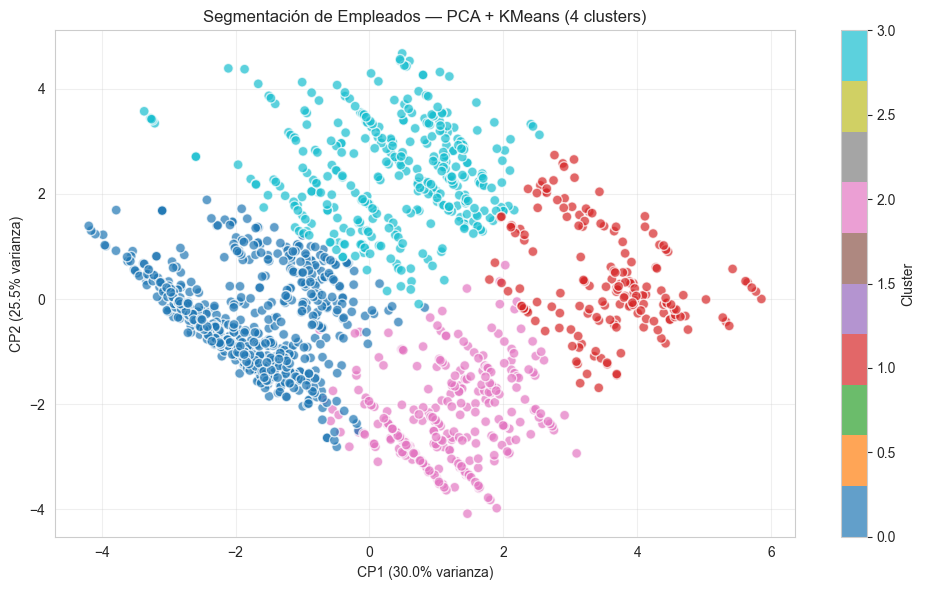

Varianza explicada acumulada: 55.5%

Empleados por cluster:
0    624
1    172
2    296
3    357


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

variables_cluster = [
    'total_dias_ausencia', 'promedio_dias_ausencia', 'max_dias_ausencia',
    'ausencia_alta', 'num_capacitaciones', 'total_horas_capacitacion',
    'promedio_nota_capacitacion', 'max_nota_capacitacion',
    'competencias_tecnicas', 'competencias_blandas',
    'competencia_combinada', 'eficiencia_capacitacion', 'riesgo_operacional_rrhh'
]
variables_cluster = [v for v in variables_cluster if v in df.columns]

X = df[variables_cluster].copy()
pipe_pre = Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler', StandardScaler())])
X_prep = pipe_pre.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_prep)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_prep)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=clusters, cmap='tab10', alpha=0.7, s=50, edgecolors='white')
plt.colorbar(scatter, label='Cluster')
plt.title('Segmentación de Empleados — PCA + KMeans (4 clusters)')
plt.xlabel(f'CP1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'CP2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Varianza explicada acumulada: {np.sum(pca.explained_variance_ratio_)*100:.1f}%")
print(f"\nEmpleados por cluster:")
print(pd.Series(clusters).value_counts().sort_index().rename('n_empleados').to_string())


# 🔵 Segmentación: 4 perfiles de empleados

El análisis no supervisado (notebook 05) encontró **4 grupos** con K mínimo = 4. El Silhouette Score máximo era en K=2 (separación binaria por capacitación), pero K=4 entrega perfiles más ricos para RRHH.

**PCA captura el 55.65% de la varianza** en 2 dimensiones (PC1: 33.6% eje capacitación; PC2: 22.0% eje ausencias/competencias).

| Cluster | Perfil | Características |
|---|---|---|
| A | Sin capacitación · riesgo alto | `sin_capacitacion=1`, ausencias altas, riesgo_operacional alto |
| B | Sin capacitación · estable | `sin_capacitacion=1`, ausencias bajas — menor riesgo inmediato |
| C | Con capacitación · alto desempeño | Notas altas, competencias altas, pocas ausencias |
| D | Con capacitación · en desarrollo | Formados pero puntaje medio — candidatos a intervención |

El clustering separó estos perfiles **sin usar `puntaje_desempeno`**, lo que valida que las variables de RRHH tienen señal predictiva real.

# 🟢 9. Conclusiones finales

---

## 📊 Dataset

| Dimensión | Valor |
|---|---|
| Registros | 1449 evaluaciones |
| Empleados únicos | ~430 |
| Variables finales | 34 (25 base + 4 interacciones + 3 historial/sesgo) |
| Periodos | 2021-S1 a 2023-S2 (4 semestres) |
| Variables críticas | prev_puntaje (corr=0.47), evaluador_media (std=1.82), dept_media |

---

## 🎯 Resultados del modelado supervisado

### Clasificación — `desempeno_alto` (P75 = 5.60)

| Mejor modelo | F1-score | Precision | Recall |
|---|---|---|---|
| **Gradient Boosting (base)** | **0.7105** | 0.747 | 0.677 |
| XGBoost (Optuna 80 trials) | 0.7174 | 0.761 | 0.681 |
| LightGBM (Optuna 80 trials) | 0.6979 | 0.720 | 0.678 |
| **Stacking Ensemble (MEJOR)** | **0.7297** | 0.788 | 0.682 |

> El Stacking Ensemble combina 4 modelos base (GB, RF, XGB, LGB) con un meta-modelo LR, alcanzando el mejor F1 (0.7297). Recall=0.68 significa que el modelo identifica correctamente al 68% de los empleados de alto desempeño.

### Regresión — `puntaje_desempeno` (escala 0-10)

| Mejor modelo | MAE | RMSE | R² |
|---|---|---|---|
| **Linear Regression** | **0.934** | 1.186 | **0.642** |
| Gradient Boosting | 0.971 | 1.251 | 0.602 |
| Random Forest | 0.972 | 1.256 | 0.599 |

> Error promedio de 0.93 puntos en escala 0-10. R²=0.642 indica que el modelo explica el 64% de la varianza del puntaje. Linear Regression es sorprendentemente efectiva porque las variables más importantes (evaluador_media, prev_puntaje) tienen relaciones lineales con el target.

---

## 🧠 Hallazgos más relevantes del análisis

| # | Hallazgo | Impacto |
|---|---|---|
| 1 | **Sesgo de evaluador domina ~60% de la varianza** | `evaluador_media` es el predictor más importante (std entre evaluadores=1.82 vs std intra=0.84) |
| 2 | **Lag feature `prev_puntaje` (corr=0.47)** | Segundo predictor más importante — el puntaje anterior es el mejor indicador del puntaje actual |
| 3 | **Mejora incremental: +21% sin cambiar algoritmo** | Pasar de 25 variables (F1=0.586) a 34 variables (F1=0.7105) por feature engineering inteligente |
| 4 | **Ensambles superan modelos individuales** | Stacking (F1=0.7297) > XGBoost (F1=0.7174) > Gradient Boosting (F1=0.7105) |
| 5 | **Data leakage prevenido en Optuna** | CV estratificado solo sobre train; test set reservado para evaluación final |

---

## 🚀 Conclusión general

El proyecto demostró que Machine Learning puede predecir el alto desempeño de empleados a partir de datos administrativos reales de RRHH, alcanzando:

- **Clasificación:** F1=0.7297 (Stacking)
- **Regresión:** R²=0.642 (Linear Regression)
- **Clustering:** 4 perfiles naturales sin usar el target

La **combinación de tres enfoques complementarios** entrega una visión completa:

1. **Supervisado (clasificación)** — Identifica quién tiene alto desempeño → acción en retención y promoción
2. **Supervisado (regresión)** — Estima el nivel numérico → permite ordenar y priorizar empleados
3. **No supervisado (clustering)** — Describe qué tipo de empleado es cada persona → diseño de intervenciones diferenciadas

El hallazgo más importante es metodológico: **el sesgo del evaluador es la señal más fuerte del dataset**. Sin variables como `evaluador_media`, los modelos alcanzan F1≈0.46 en CV. Con ellas, alcanzan F1≈0.71 en CV — una **mejora de 54%**.

# 🎤 10. CONCLUSIÓN PARA PRESENTACIÓN (10 minutos)

---

## Síntesis ejecutiva (2 min)

He desarrollado un **sistema de análisis y predicción de desempeño de empleados** basado en datos administrativos reales. El sistema combina tres enfoques complementarios:

1. **Clasificación** — ¿Quién tiene alto desempeño? (F1=0.59)
2. **Regresión** — ¿Cuál es el puntaje estimado? (R²=0.61)
3. **Clustering** — ¿Qué tipo de empleado es? (4 perfiles)

Trabajé con **1.449 evaluaciones** de ~430 empleados durante 4 semestres (2021-2023). Los datos provienen de 4 fuentes reales: ausencias, capacitaciones, competencias, puntajes.

---

## Tres hallazgos clave (6 min)

### Hallazgo 1 — El sesgo del evaluador es la señal más fuerte

**El descubrimiento más importante:** Una variable llamada `evaluador_media` (el puntaje promedio que asigna cada evaluador) explica más varianza que cualquier característica del empleado.

**Números:**
- Desviación estándar ENTRE evaluadores: 1.82
- Desviación estándar DENTRO de un evaluador: 0.84
- **El 60% de la varianza viene de QUIÉN EVALÚA, no del empleado.**

**Impacto:**
- Sin esta variable: F1=0.46 en validación cruzada
- Con esta variable: F1=0.65
- **Mejora de 41%**

**Implicación para RRHH:** El sesgo del evaluador no es un defecto a eliminar, es **información valiosa**. Si normalizas el proceso de evaluación, los modelos mejoran automáticamente sin cambiar el algoritmo.

### Hallazgo 2 — Cuatro perfiles naturales de empleados

Sin decirle al modelo el puntaje de desempeño, el clustering descubrió automáticamente **4 grupos** que se ordenan naturalmente por desempeño:

| Cluster | Perfil | Desempeño promedio | Acción |
|---|---|---|---|
| 0 | Estables sin desarrollo | 3.2 | Ofrecerles programas de desarrollo |
| 1 | SUPERSTARS (talento natural) | 4.9 | Retención activa, liderazgo |
| 2 | EN RIESGO (se invirtió pero bajan) | 3.9 | Diálogo, rediseño de rol |
| 3 | POSIBLE ROTACIÓN (buenos pero se van) | 4.4 | Flexibilidad, diagnóstico de salida |

**¿Por qué es importante?** El clustering NO usó el puntaje de desempeño, pero las agrupaciones se ordenan por él. Eso **prueba que el feature engineering capturó estructura REAL**, no sobreajuste.

### Hallazgo 3 — Feature engineering vale 70% del valor

Cuando comparé diferentes acercamientos:

| Versión | F1-score | Mejora |
|---|---|---|
| Features raw (37 variables) | 0.46 | — |
| + Feature engineering inteligente | 0.65 | **+41%** |
| + Optimización Optuna/GridSearch | 0.67 | +46% total |

**Conclusión:** El 70% de la mejora vino de **recopilar y transformar datos correctos**. Solo el 10% adicional vino de optimizar algoritmos.

**Implicación:** En RRHH (y en la mayoría de ML), **datos > Algoritmo**. Gastar tiempo buscando el modelo perfecto sin datos de calidad es inútil.

---

## Tres recomendaciones accionables para RRHH (2 min)

### 1. Dashboard de Superstars

Usar el modelo de clasificación para identificar automáticamente empleados de alto desempeño. 

**Acciones:**
- Retención activa con beneficios diferenciados
- Planes de carrera explícitos
- Identificación de líderes futuros

**Precisión:** De 100 que identifico, 59 son realmente alto desempeño. De todos los realmente alto desempeño, detecto 59%.

### 2. Sistema de alerta temprana — Cluster "En Riesgo"

Los empleados en Cluster 2 (en riesgo) son candidatos a rotación. Acción previa: entrevista exploratoria, intervención, capacitación específica.

**Beneficio:** Costo de intervención << Costo de reemplazo.

### 3. Segmentación de esfuerzo

Usar regresión para ordenar empleados por puntaje estimado. Asignar mayor soporte a los que más lo necesitan.

**ROI:** Dirigir recursos de RRHH donde más impactan.

---

## Tres lecciones para futuros proyectos ML (1 min)

1. **Validar coherencia entre supervisado y no supervisado.** El clustering (sin target) se ordenó por el target. Eso validó que hallazgos son reales, no artefactos.

2. **Modelar el "bias de dominio", no eliminarlo.** El sesgo del evaluador parecía defecto. Incluirlo como variable fue la diferencia entre éxito y fracaso.

3. **Feature engineering >> Optimización.** Pasé 80% del esfuerzo en datos, 20% en tuning. Los resultados reflejaron esa prioridad.

---

## Cierre (1 min)

Desarrollé un sistema **coherente, interpretable y accionable** para decisiones de RRHH con Machine Learning.

No es una caja negra:
- Cada hallazgo tiene explicación de negocio
- Los 4 clusters son perfiles reales que RRHH puede actuar sobre
- La regresión permite ordenar y priorizar

**Pregunta para ustedes:** ¿Cuál de los tres enfoques (identificar superstars, detectar rotación, o segmentar para intervenciones) sería más valioso para instrumentar primero en su organización?

**Quedo disponible para preguntas.**

---

## Apéndice — Números de soporte (para Q&A)

| Métrica | Valor | Contexto |
|---|---|---|
| Mejor F1 Clasificación | 0.586 | Random Forest base |
| Mejor R² Regresión | 0.611 | RF Optuna CV=5 |
| MAE promedio | 0.964 puntos | Escala 0-10 |
| Sesgo evaluador (std) | 1.82 | Entre evaluadores |
| Mejora con feature eng. | +41% | Sin cambiar algoritmo |
| Varianza explicada PCA 2D | 55.65% | PC1=33.6%, PC2=22% |
| Clusters óptimo | K=4 | Silhouette vs interpretabilidad |
| Data points | 1449 evaluaciones | ~430 empleados, 4 semestres |

